# Distribuições contínuas

**Tema:** Estatística › Distribuições de Probabilidade

Aqui a pergunta muda de "quantos?" para "quanto?" e "quando?". Tempo até a
falha, valor de um sinistro, latência de uma chamada, receita de um cliente.

> **A ideia que amarra o notebook:** para variáveis contínuas,
> $P(X = x) = 0$ para todo $x$. Só existe probabilidade de **intervalos**. A
> densidade $f(x)$ não é probabilidade — é probabilidade *por unidade de x*, e
> pode perfeitamente valer 5 ou 100. O que precisa somar 1 é a área.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(99)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Densidade não é probabilidade

Vamos deixar isso concreto de uma vez por todas com uma uniforme estreita.

Uniforme(0.0, 0.1) -> densidade f(x) = 10.0
Área total = base × altura = 0.1 × 10.0 = 1.0  ✓

f(x) = 10 NÃO significa 'probabilidade 10'. Significa 10 por unidade de x.
P(0.02 <= X <= 0.03) = 0.10


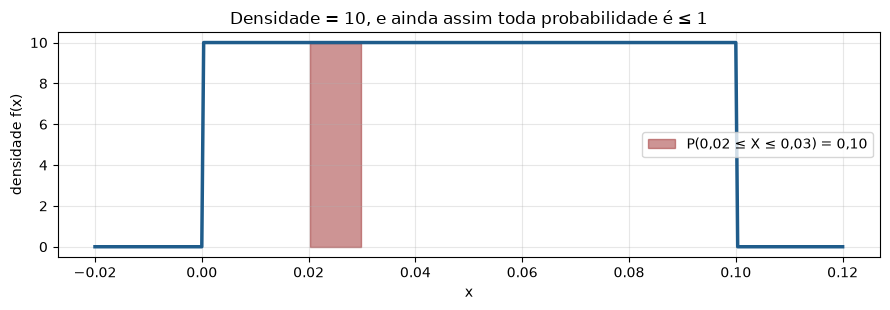

In [2]:
# Uniforme entre 0 e 0.1: a densidade tem de valer 10 para a área ser 1.
a, b = 0.0, 0.1
densidade = 1 / (b - a)
print(f"Uniforme({a}, {b}) -> densidade f(x) = {densidade:.1f}")
print(f"Área total = base × altura = {(b-a):.1f} × {densidade:.1f} = "
      f"{(b-a)*densidade:.1f}  ✓")
print()
print("f(x) = 10 NÃO significa 'probabilidade 10'. Significa 10 por unidade de x.")
print(f"P(0.02 <= X <= 0.03) = {(0.03-0.02) * densidade:.2f}")

fig, ax = plt.subplots(figsize=(9, 3.2))
grade = np.linspace(-0.02, 0.12, 400)
ax.plot(grade, stats.uniform.pdf(grade, a, b - a), lw=2.5, color=AZUL)
ax.fill_between(grade, stats.uniform.pdf(grade, a, b - a),
                where=(grade >= 0.02) & (grade <= 0.03), color=VERMELHO, alpha=0.5,
                label="P(0,02 ≤ X ≤ 0,03) = 0,10")
ax.set_ylabel("densidade f(x)")
ax.set_xlabel("x")
ax.set_title("Densidade = 10, e ainda assim toda probabilidade é ≤ 1")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Normal: as três razões pelas quais ela domina

### 2.1 A regra 68–95–99,7 (e a letra miúda)

In [3]:
mu, sigma = 100.0, 15.0
for k in (1, 2, 3):
    dentro = stats.norm.cdf(mu + k*sigma, mu, sigma) - stats.norm.cdf(mu - k*sigma, mu, sigma)
    print(f"±{k} desvio(s)-padrão -> {dentro:7.4%} da massa")

print("\nMas essa regra SÓ vale para dados realmente normais. Compare:")
n = 500_000
amostras_teste = {
    "Normal": rng.normal(0, 1, n),
    "Log-normal": rng.lognormal(0, 1, n),
    "t de Student (df=3)": rng.standard_t(3, n),
    "Exponencial": rng.exponential(1, n),
}
print(f"\n{'distribuição':22s} {'dentro de ±1s':>15s} {'±2s':>9s} {'±3s':>9s}")
print("-" * 60)
for nome, v in amostras_teste.items():
    m, s = v.mean(), v.std(ddof=1)
    linha = [np.mean(np.abs(v - m) <= k * s) for k in (1, 2, 3)]
    print(f"{nome:22s} {linha[0]:>14.2%} {linha[1]:>9.2%} {linha[2]:>9.2%}")

±1 desvio(s)-padrão -> 68.2689% da massa
±2 desvio(s)-padrão -> 95.4500% da massa
±3 desvio(s)-padrão -> 99.7300% da massa

Mas essa regra SÓ vale para dados realmente normais. Compare:

distribuição             dentro de ±1s       ±2s       ±3s
------------------------------------------------------------
Normal                         68.20%    95.45%    99.73%
Log-normal                     90.92%    96.27%    98.18%
t de Student (df=3)            81.46%    95.83%    98.59%
Exponencial                    86.42%    95.03%    98.18%


Repare na exponencial: **86%** dentro de ±1 desvio-padrão, contra os 68%
prometidos. E na t de Student: 99,3% dentro de ±3s, contra 99,7% — parece
pouco, mas significa **mais que o dobro** de eventos extremos.

### 2.2 Máxima entropia: por que a normal é a escolha "honestamente ignorante"

Entre todas as distribuições com uma dada média e variância, a normal é a que
tem **maior entropia** — ou seja, a que assume o mínimo além do que foi
especificado. Vamos verificar numericamente.

In [4]:
def entropia_diferencial(amostra, bins=200):
    """Estimativa de entropia por histograma (em nats)."""
    hist, bordas = np.histogram(amostra, bins=bins, density=True)
    larguras = np.diff(bordas)
    p = hist[hist > 0]
    w = larguras[hist > 0]
    return -np.sum(p * np.log(p) * w)

alvo_media, alvo_var = 0.0, 1.0
candidatas = {
    "Normal(0, 1)": rng.normal(0, 1, 400_000),
    "Uniforme (mesma variância)": rng.uniform(-np.sqrt(3), np.sqrt(3), 400_000),
    "Laplace (mesma variância)": rng.laplace(0, 1/np.sqrt(2), 400_000),
    "Triangular (mesma variância)": rng.triangular(-np.sqrt(6), 0, np.sqrt(6), 400_000),
}
print(f"{'distribuição':32s} {'média':>7s} {'variância':>10s} {'entropia':>10s}")
print("-" * 63)
for nome, v in candidatas.items():
    print(f"{nome:32s} {v.mean():>7.3f} {v.var(ddof=1):>10.3f} "
          f"{entropia_diferencial(v):>10.4f}")
print(f"\nEntropia teórica da N(0,1) = {0.5*np.log(2*np.pi*np.e):.4f} nats")
print("Todas têm a MESMA média e variância. A normal tem a MAIOR entropia.")

distribuição                       média  variância   entropia
---------------------------------------------------------------
Normal(0, 1)                      -0.002      0.999     1.4182
Uniforme (mesma variância)        -0.000      0.999     1.2422
Laplace (mesma variância)         -0.000      1.002     1.3481
Triangular (mesma variância)       0.002      1.000     1.3958

Entropia teórica da N(0,1) = 1.4189 nats
Todas têm a MESMA média e variância. A normal tem a MAIOR entropia.


> **Por que isso importa na prática:** quando você assume normalidade sem ter
> informação adicional, está fazendo a suposição *menos comprometida* possível
> dado o que sabe. O problema não é assumir normalidade por ignorância — é
> assumi-la quando você **tem** evidência contrária (assimetria visível, cauda
> pesada no QQ-plot) e escolhe ignorar.

## 3. Log-normal: quando os efeitos se multiplicam

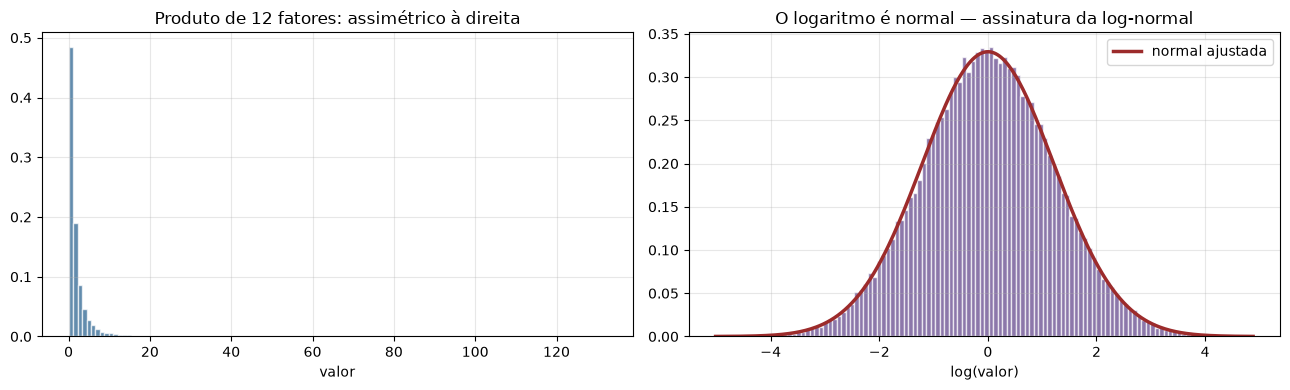

Média observada   = 2.0827
Média teórica exp(μ + σ²/2) = 2.0854
Mediana observada = 1.0003
Mediana teórica exp(μ)      = 1.0011

Razão média/mediana = 2.0821
Valor teórico exp(σ²/2)     = 2.0832


In [5]:
# Simulação do mecanismo gerador: 12 fatores multiplicativos independentes.
# Pense em: tráfego × sazonalidade × qualidade da página × preço × ...
n_sim, n_fatores = 100_000, 12
fatores = rng.lognormal(mean=0, sigma=0.35, size=(n_sim, n_fatores))
produto = fatores.prod(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(produto, bins=120, density=True, color=AZUL, alpha=0.7, edgecolor="white")
ax1.set_title("Produto de 12 fatores: assimétrico à direita")
ax1.set_xlabel("valor")
ax2.hist(np.log(produto), bins=120, density=True, color=ROXO, alpha=0.7,
         edgecolor="white")
grade = np.linspace(np.log(produto).min(), np.log(produto).max(), 300)
ax2.plot(grade, stats.norm.pdf(grade, np.log(produto).mean(),
                               np.log(produto).std(ddof=1)),
         lw=2.5, color=VERMELHO, label="normal ajustada")
ax2.set_title("O logaritmo é normal — assinatura da log-normal")
ax2.set_xlabel("log(valor)")
ax2.legend()
plt.tight_layout()
plt.show()

# A relação média-mediana é o diagnóstico numérico
mu_log, sigma_log = np.log(produto).mean(), np.log(produto).std(ddof=1)
print(f"Média observada   = {produto.mean():.4f}")
print(f"Média teórica exp(μ + σ²/2) = {np.exp(mu_log + sigma_log**2/2):.4f}")
print(f"Mediana observada = {np.median(produto):.4f}")
print(f"Mediana teórica exp(μ)      = {np.exp(mu_log):.4f}")
print(f"\nRazão média/mediana = {produto.mean()/np.median(produto):.4f}")
print(f"Valor teórico exp(σ²/2)     = {np.exp(sigma_log**2/2):.4f}")

> **No mercado:** a razão média/mediana é um KPI diagnóstico gratuito. Se o
> ticket médio é 1,8× a mediana, você tem $\sigma \approx 1{,}08$ na escala log
> — cauda pesada o suficiente para que qualquer previsão de receita baseada em
> média seja instável mês a mês.

## 4. Exponencial e Weibull: a curva da banheira

A pergunta central da confiabilidade não é "quanto tempo dura em média?", e sim
**"a chance de falhar agora aumenta com a idade?"**. Isso é a *taxa de risco*
(hazard rate):

$$h(t) = \frac{f(t)}{1 - F(t)} = \frac{\text{densidade de falhar em } t}{\text{fração ainda viva em } t}$$

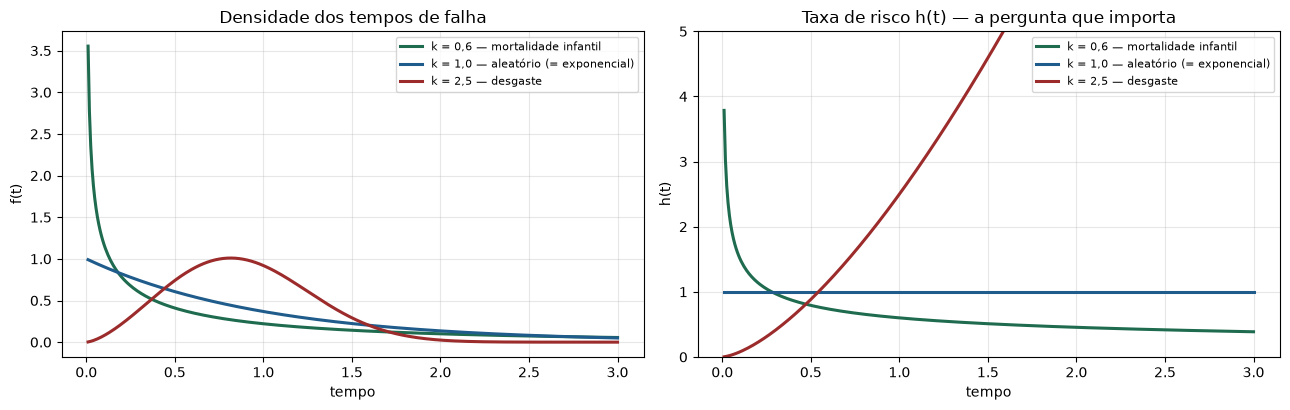

Leitura do painel da direita:
  k < 1 : risco CAI com o tempo  -> quem sobreviveu ao início é confiável
  k = 1 : risco CONSTANTE        -> sem memória; idade é irrelevante
  k > 1 : risco SOBE com o tempo -> substituição preventiva faz sentido


In [6]:
t = np.linspace(0.01, 3.0, 400)
LAMBDA_W = 1.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

for k_forma, cor, rotulo in [
        (0.6, VERDE, "k = 0,6 — mortalidade infantil"),
        (1.0, AZUL, "k = 1,0 — aleatório (= exponencial)"),
        (2.5, VERMELHO, "k = 2,5 — desgaste")]:
    pdf = stats.weibull_min.pdf(t, k_forma, scale=LAMBDA_W)
    sf = stats.weibull_min.sf(t, k_forma, scale=LAMBDA_W)   # sf = 1 - CDF
    ax1.plot(t, pdf, lw=2.2, color=cor, label=rotulo)
    ax2.plot(t, pdf / sf, lw=2.2, color=cor, label=rotulo)

ax1.set_title("Densidade dos tempos de falha")
ax1.set_xlabel("tempo")
ax1.set_ylabel("f(t)")
ax1.legend(fontsize=8)

ax2.set_title("Taxa de risco h(t) — a pergunta que importa")
ax2.set_xlabel("tempo")
ax2.set_ylabel("h(t)")
ax2.set_ylim(0, 5)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Leitura do painel da direita:")
print("  k < 1 : risco CAI com o tempo  -> quem sobreviveu ao início é confiável")
print("  k = 1 : risco CONSTANTE        -> sem memória; idade é irrelevante")
print("  k > 1 : risco SOBE com o tempo -> substituição preventiva faz sentido")

> **Consequência de negócio direta:** manutenção preventiva (trocar a peça
> antes de falhar) só faz sentido econômico se $k > 1$. Se $k = 1$, trocar uma
> peça velha por uma nova **não reduz o risco em nada** — você está gastando
> dinheiro à toa. Se $k < 1$, trocar é *pior*: você substitui uma peça que já
> provou ser boa por uma que ainda pode ter defeito de fábrica.

### A falta de memória da exponencial, medida

In [7]:
vida = rng.exponential(scale=1000, size=500_000)   # MTBF de 1000 horas
print("Vida útil restante ESPERADA, dado que já sobreviveu s horas:")
print(f"{'s (horas já vividas)':>22s} {'E[resto | X > s]':>18s}")
print("-" * 42)
for s in [0, 500, 1000, 2000, 4000]:
    restante = vida[vida > s] - s
    if len(restante) > 50:
        print(f"{s:>22,d} {restante.mean():>18,.1f}")
print("\nSempre ~1000 h. O componente não envelhece — e é justamente por isso")
print("que a exponencial é um modelo ruim para peças mecânicas reais.")

Vida útil restante ESPERADA, dado que já sobreviveu s horas:
  s (horas já vividas)   E[resto | X > s]
------------------------------------------
                     0              999.1
                   500              997.6
                 1,000              999.2
                 2,000              999.4
                 4,000            1,027.3

Sempre ~1000 h. O componente não envelhece — e é justamente por isso
que a exponencial é um modelo ruim para peças mecânicas reais.


## 5. Beta: a distribuição de uma probabilidade

A Beta vive em $[0,1]$, o que a torna a candidata natural para representar
**incerteza sobre uma taxa**. Interpretação prática: $\text{Beta}(\alpha,
\beta)$ representa a crença de quem observou $\alpha-1$ sucessos e $\beta-1$
fracassos.

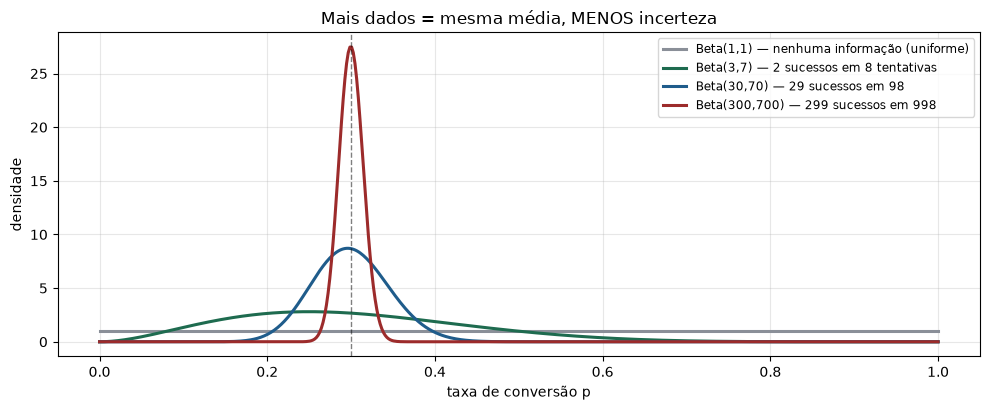

Beta(1,1) — nenhuma informação (uniforme)    média=0.500  IC95%=[0.025, 0.975]  largura=0.950
Beta(3,7) — 2 sucessos em 8 tentativas       média=0.300  IC95%=[0.075, 0.600]  largura=0.525
Beta(30,70) — 29 sucessos em 98              média=0.300  IC95%=[0.215, 0.393]  largura=0.178
Beta(300,700) — 299 sucessos em 998          média=0.300  IC95%=[0.272, 0.329]  largura=0.057


In [8]:
grade = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(10, 4.2))
cenarios = [
    (1, 1, "Beta(1,1) — nenhuma informação (uniforme)", "#8A8F98"),
    (3, 7, "Beta(3,7) — 2 sucessos em 8 tentativas", VERDE),
    (30, 70, "Beta(30,70) — 29 sucessos em 98", AZUL),
    (300, 700, "Beta(300,700) — 299 sucessos em 998", VERMELHO),
]
for alfa, beta, rotulo, cor in cenarios:
    ax.plot(grade, stats.beta.pdf(grade, alfa, beta), lw=2.2, color=cor, label=rotulo)
ax.axvline(0.30, ls="--", color="black", lw=1, alpha=0.5)
ax.set_xlabel("taxa de conversão p")
ax.set_ylabel("densidade")
ax.set_title("Mais dados = mesma média, MENOS incerteza")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

for alfa, beta, rotulo, _ in cenarios:
    media = alfa / (alfa + beta)
    lo, hi = stats.beta.ppf([0.025, 0.975], alfa, beta)
    print(f"{rotulo:44s} média={media:.3f}  IC95%=[{lo:.3f}, {hi:.3f}]  "
          f"largura={hi-lo:.3f}")

Note que a média fica em 0,30 nos três casos informativos, mas o intervalo
encolhe por um fator de ~10 quando o $n$ cresce 100×. Isso é o
$1/\sqrt{n}$ do TLC aparecendo de novo — vamos formalizá-lo no próximo
notebook.

> **No mercado:** esta é literalmente a máquina por trás do **Thompson
> sampling**, o algoritmo de *multi-armed bandit* usado para alocar tráfego em
> tempo real. Cada variante tem sua Beta; a cada requisição você sorteia um
> valor de cada Beta e serve a variante que sorteou o maior. Variantes
> incertas são exploradas; variantes comprovadamente ruins somem sozinhas.

## 6. Como as distribuições se conectam

Elas não são uma lista — são uma rede de relações.

In [9]:
relacoes = pd.DataFrame([
    ("Bernoulli", "soma de n", "Binomial"),
    ("Binomial", "n→∞, p→0, np=λ", "Poisson"),
    ("Poisson", "tempos entre eventos", "Exponencial"),
    ("Exponencial", "soma de k", "Gama"),
    ("Exponencial", "generaliza a taxa de risco", "Weibull"),
    ("Normal padrão", "soma de k quadrados", "Qui-quadrado"),
    ("Normal / √(Qui²/k)", "razão", "t de Student"),
    ("Gama", "razão normalizada", "Beta"),
    ("Normal", "exponencial de", "Log-normal"),
    ("Qualquer uma", "média de n amostras (TLC)", "Normal"),
], columns=["Ponto de partida", "Operação", "Resultado"])
relacoes

,Ponto de partida,Operação,Resultado
0,Bernoulli,soma de n,Binomial
1,Binomial,"n→∞, p→0, np=λ",Poisson
2,Poisson,tempos entre eventos,Exponencial
3,Exponencial,soma de k,Gama
4,Exponencial,generaliza a taxa de risco,Weibull
5,Normal padrão,soma de k quadrados,Qui-quadrado
6,Normal / √(Qui²/k),razão,t de Student
7,Gama,razão normalizada,Beta
8,Normal,exponencial de,Log-normal
9,Qualquer uma,média de n amostras (TLC),Normal


Vale a pena memorizar essa tabela em vez de memorizar fórmulas: com ela você
reconstrói qualquer resultado.

## 7. Exercícios

1. Gere 100.000 latências log-normais com mediana 80 ms. Calcule p50, p95, p99
   e a média. Se seu SLA é "p99 abaixo de 500 ms", qual $\sigma$ máximo você
   pode tolerar?
2. Ajuste uma Weibull a dados simulados de falha com `stats.weibull_min.fit`.
   Recupere o $k$ verdadeiro. A partir de qual $n$ a estimativa fica confiável?
3. Um processo tem 3 etapas em série, cada uma com tempo exponencial de média
   2 min. Qual a distribuição do tempo total? Simule e confirme que é uma Gama
   com `shape=3`. Qual é a probabilidade de o processo total passar de 10 min?
4. Compare graficamente t de Student com df = 1, 3, 10, 30 e 100 contra a
   normal padrão. A partir de qual df a diferença fica visualmente
   imperceptível? E nos quantis extremos (p99,9)?

## Próximo passo

`03-tlc-e-lei-dos-grandes-numeros.ipynb` — os dois teoremas que fazem a
estatística inteira funcionar, e as condições em que eles falham.